Threshold Precision Recall    F1 Score  
----------------------------------------
0.00      0.75      1.00      0.86      
0.01      0.75      1.00      0.86      
0.02      0.75      1.00      0.86      
0.03      0.75      1.00      0.86      
0.04      0.75      1.00      0.86      
0.05      0.75      1.00      0.86      
0.06      0.75      1.00      0.86      
0.07      0.75      1.00      0.86      
0.08      0.75      1.00      0.86      
0.09      0.75      1.00      0.86      
0.10      0.75      1.00      0.86      
0.11      0.75      1.00      0.86      
0.12      0.75      1.00      0.86      
0.13      0.75      1.00      0.86      
0.14      0.75      1.00      0.86      
0.15      0.75      1.00      0.86      
0.16      0.75      1.00      0.86      
0.17      0.75      1.00      0.86      
0.18      0.75      1.00      0.86      
0.19      0.75      1.00      0.86      
0.20      0.75      1.00      0.86      
0.21      0.75      1.00      0.86      
0.22      0.75  

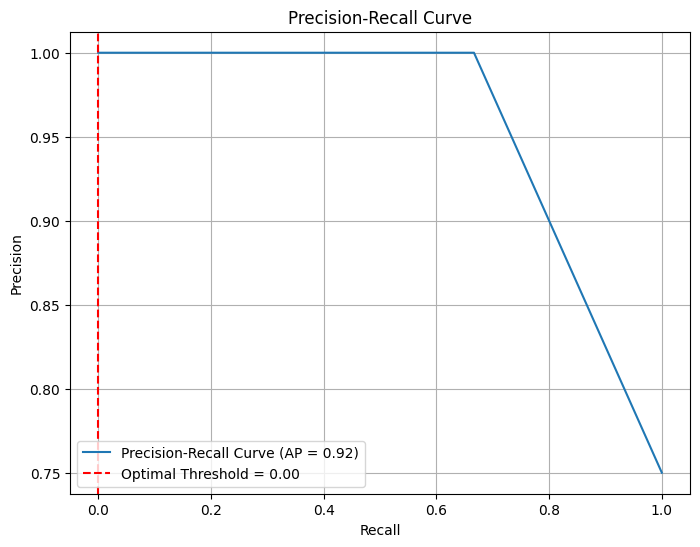

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, average_precision_score

# Function to find the optimal threshold
def find_optimal_threshold(detections, labels):
    thresholds = np.linspace(0, 1, 100)  # Test 100 thresholds between 0 and 1
    best_threshold = 0
    best_f1 = 0

    print(f"{'Threshold':<10}{'Precision':<10}{'Recall':<10}{'F1 Score':<10}")
    print("-" * 40)

    for thresh in thresholds:
        preds = (detections >= thresh).astype(int)
        tp = np.sum((preds == 1) & (labels == 1))
        fp = np.sum((preds == 1) & (labels == 0))
        fn = np.sum((preds == 0) & (labels == 1))
        
        precision = tp / (tp + fp) if tp + fp > 0 else 0
        recall = tp / (tp + fn) if tp + fn > 0 else 0
        f1 = f1_score(labels, preds)
        
        print(f"{thresh:<10.2f}{precision:<10.2f}{recall:<10.2f}{f1:<10.2f}")
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    
    return best_threshold, best_f1

# Example data
detections = np.array([0.3, 0.5, 0.3, 0.9])  # Example predicted scores
labels = np.array([1, 1, 0, 1])  # Example ground truth

# Find optimal threshold
optimal_thresh, best_f1 = find_optimal_threshold(detections, labels)
print(f"\nOptimal Threshold: {optimal_thresh:.2f}, Best F1 Score: {best_f1:.2f}")

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(labels, detections)
print(precision)
print(recall)
print(thresholds)
average_precision = average_precision_score(labels, detections)

# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
plt.axvline(x=optimal_thresh, color='r', linestyle='--', label=f'Optimal Threshold = {optimal_thresh:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show()


Threshold Precision Recall    F1 Score  
----------------------------------------
0.00      0.75      1.00      0.86      
0.01      0.75      1.00      0.86      
0.02      0.75      1.00      0.86      
0.03      0.75      1.00      0.86      
0.04      0.75      1.00      0.86      
0.05      0.75      1.00      0.86      
0.06      0.75      1.00      0.86      
0.07      0.75      1.00      0.86      
0.08      0.75      1.00      0.86      
0.09      0.75      1.00      0.86      
0.10      0.75      1.00      0.86      
0.11      0.75      1.00      0.86      
0.12      0.75      1.00      0.86      
0.13      0.75      1.00      0.86      
0.14      0.75      1.00      0.86      
0.15      0.75      1.00      0.86      
0.16      0.75      1.00      0.86      
0.17      0.75      1.00      0.86      
0.18      0.75      1.00      0.86      
0.19      0.75      1.00      0.86      
0.20      0.75      1.00      0.86      
0.21      0.75      1.00      0.86      
0.22      0.75  

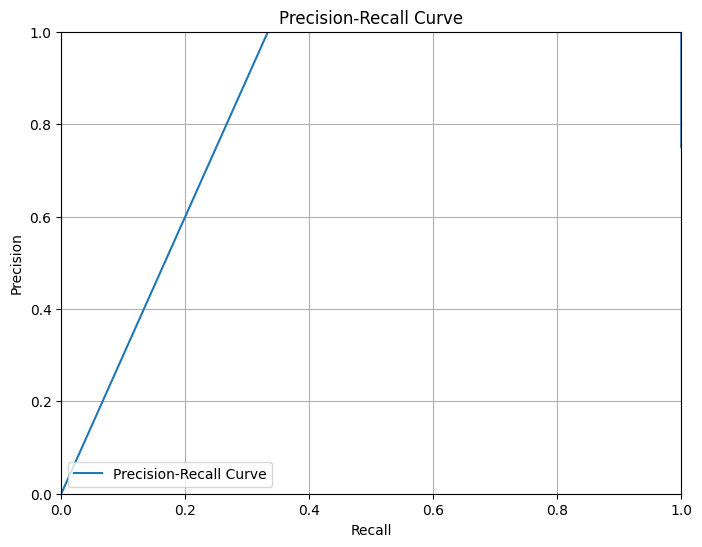

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, average_precision_score

# Function to calculate precision, recall, and F1-score at fixed thresholds
def calculate_metrics_at_thresholds(detections, labels, thresholds):
    precisions = []
    recalls = []
    f1_scores = []

    print(f"{'Threshold':<10}{'Precision':<10}{'Recall':<10}{'F1 Score':<10}")
    print("-" * 40)

    for thresh in thresholds:
        preds = (detections >= thresh).astype(int)
        tp = np.sum((preds == 1) & (labels == 1))
        fp = np.sum((preds == 1) & (labels == 0))
        fn = np.sum((preds == 0) & (labels == 1))
        
        precision = tp / (tp + fp) if tp + fp > 0 else 0
        recall = tp / (tp + fn) if tp + fn > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        
        print(f"{thresh:<10.2f}{precision:<10.2f}{recall:<10.2f}{f1:<10.2f}")

    return np.array(precisions), np.array(recalls), np.array(f1_scores)

# Example data
detections = np.array([0.8, 0.6, 0.3, 0.9])  # Example predicted scores
labels = np.array([1, 1, 0, 1])  # Example ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0, 1, 100)  # Uniform thresholds from 0 to 1

# Calculate precision, recall, and F1-score for each threshold
precisions, recalls, f1_scores = calculate_metrics_at_thresholds(detections, labels, thresholds)

# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='Precision-Recall Curve')
plt.xlim(0, 1)  # Set x-axis (recall) to range [0, 1]
plt.ylim(0, 1)  # Set y-axis (precision) to range [0, 1]
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show()


[0.6  0.75 1.   1.   1.   1.  ] [1.         1.         1.         0.66666667 0.33333333 0.        ] [0.6  0.7  0.75 0.8  0.9 ]
Optimal Threshold: 0.75
Precision at optimal threshold: 1.0
Recall at optimal threshold: 1.0
F1 Score at optimal threshold: 1.0


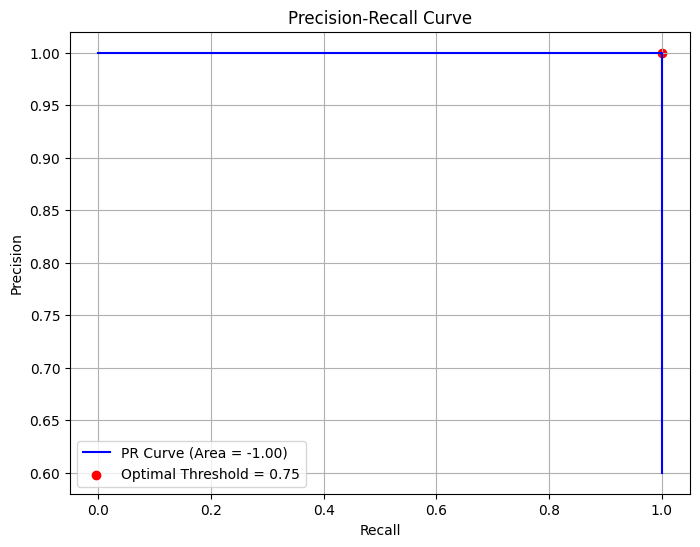

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

def compute_iou(box1, box2):
    # Compute the Intersection over Union (IoU) between two boxes
    x1, y1, x2, y2 = box1
    x1_gt, y1_gt, x2_gt, y2_gt = box2

    x_left = max(x1, x1_gt)
    y_top = max(y1, y1_gt)
    x_right = min(x2, x2_gt)
    y_bottom = min(y2, y2_gt)

    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2_gt - x1_gt) * (y2_gt - y2_gt)

    union_area = box1_area + box2_area - intersection_area
    iou = intersection_area / union_area if union_area > 0 else 0
    return iou

def calculate_precision_recall_for_multiple_images(pred_images, true_images, iou_threshold=0.5):
    all_tp = []
    all_fp = []
    all_fn = []
    all_pred_scores = []

    for pred_boxes, pred_scores, true_boxes in zip(pred_images, pred_scores_images, true_images):
        # Sort predictions by their confidence score
        sorted_indices = np.argsort(pred_scores)[::-1]
        pred_boxes = np.array(pred_boxes)[sorted_indices]
        pred_scores = np.array(pred_scores)[sorted_indices]

        tp = np.zeros(len(pred_scores))  # True positives
        fp = np.zeros(len(pred_scores))  # False positives
        fn = np.zeros(len(true_boxes))  # False negatives

        for i, pred_box in enumerate(pred_boxes):
            iou_max = 0
            best_gt_idx = -1
            # Find the best matching ground truth box for this prediction
            for j, true_box in enumerate(true_boxes):
                iou = compute_iou(pred_box, true_box)
                if iou > iou_max:
                    iou_max = iou
                    best_gt_idx = j
            
            if iou_max >= iou_threshold:
                tp[i] = 1
                fn[best_gt_idx] = 1
            else:
                fp[i] = 1

        # Add to the lists
        all_tp.extend(tp)
        all_fp.extend(fp)
        all_fn.extend(fn)
        all_pred_scores.extend(pred_scores)

    # Precision and Recall calculation across all images
    precision, recall, thresholds = precision_recall_curve(all_tp, all_pred_scores)
    print(precision, recall, thresholds)
    
    # Find the optimal threshold (maximizing F1 score or based on your desired precision/recall)
    f1 = 2 * (precision * recall) / (precision + recall)

    return precision, recall, f1, thresholds

# Example data for multiple images (replace with actual data)
# Predicted scores (confidence scores) for each detection
pred_scores_images = [
    [0.9, 0.75, 0.6],  # Predicted scores for image 1
    [0.8, 0.7]         # Predicted scores for image 2
]

# Ground truth bounding boxes for each image: (x1, y1, x2, y2)
true_images = [
    [(50, 50, 100, 100), (150, 150, 200, 200)],  # True boxes for image 1
    [(80, 80, 130, 130)]                         # True boxes for image 2
]

# Predicted bounding boxes for each image (same format as true boxes)
pred_images = [
    [(48, 48, 102, 102), (148, 148, 202, 202), (10, 10, 50, 50)],  # Predicted boxes for image 1
    [(78, 78, 130, 130), (160, 160, 205, 205)]                      # Predicted boxes for image 2
]

# Calculate precision, recall, and F1 score for different thresholds
precision, recall, f1, thresholds = calculate_precision_recall_for_multiple_images(pred_images, true_images, iou_threshold=0.5)

# Find the optimal threshold (maximizing F1 score)
optimal_threshold_idx = np.argmax(f1)
optimal_threshold = thresholds[optimal_threshold_idx]

print(f"Optimal Threshold: {optimal_threshold}")
print(f"Precision at optimal threshold: {precision[optimal_threshold_idx]}")
print(f"Recall at optimal threshold: {recall[optimal_threshold_idx]}")
print(f"F1 Score at optimal threshold: {f1[optimal_threshold_idx]}")

# Plotting Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', label='PR Curve (Area = %0.2f)' % np.trapz(precision, recall))
plt.scatter(recall[optimal_threshold_idx], precision[optimal_threshold_idx], color='r', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [44]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text = """This is the first paragraph, . It has some content 
to demonstrate how text 
is, split base donthe chunkaa a size.
This is the second paragraph. 
It also contains some content, that will allow us to see how chunking occurs with separators. Third paragraph starts here, and more content is added. We will see how the chunking works when separators are applied."""

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
    separators=["\n\n", "\n", ",", " ", ""]
)

chunks = text_splitter.split_text(text)

print("Chunks after splitting:")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} (Length {len(chunk)}):\n{chunk}\n")


Chunks after splitting:
Chunk 1 (Length 75):
This is the first paragraph, . It has some content 
to demonstrate how text

Chunk 2 (Length 67):
is, split base donthe chunkaa a size.
This is the second paragraph.

Chunk 3 (Length 29):
It also contains some content

Chunk 4 (Length 92):
, that will allow us to see how chunking occurs with separators. Third paragraph starts here

Chunk 5 (Length 92):
, and more content is added. We will see how the chunking works when separators are applied.



In [35]:
chunks

['This is the first paragraph, . It has some content to demonstrate how',
 'text is split basedonthechunkaaa size.\nThis is the second paragraph.',
 'It also contains some content that will allow us to see how chunking occurs with separators. Third',
 'separators. Third paragraph starts here, and more content is added. We will see how the chunking',
 'how the chunking works when separators are applied.']

In [55]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text = """
Section 1:
This is the first paragraph of section 1. This should be chunked separately.

Section 2:
This is the first paragraph of section 2. Also, we want this section as a whole.
Additional information about section 2 continues here.

Section 3:
starts here with some content. Keep all of this together.
"""

sections = text.split("Section")

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", " ", ""]
)

chunks = []
for section in sections:
    if section.strip():
        section_chunks = text_splitter.split_text(section)
        chunks.extend(section_chunks)

print("Chunks after splitting:")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} (Length {len(chunk)}):\n{chunk}\n")


Chunks after splitting:
Chunk 1 (Length 79):
1:
This is the first paragraph of section 1. This should be chunked separately.

Chunk 2 (Length 138):
2:
This is the first paragraph of section 2. Also, we want this section as a whole.
Additional information about section 2 continues here.

Chunk 3 (Length 60):
3:
starts here with some content. Keep all of this together.



In [ ]:
import os
import csv
import cv2
from ultralytics import YOLO  # Replace with your YOLO library
import numpy as np

def parse_ground_truth(txt_file, target_class=2):
    """
    Parse ground truth bounding boxes from the .txt file for the target class.
    """
    ground_truth_boxes = []
    with open(txt_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            class_id, cx, cy, w, h = map(float, parts)
            if int(class_id) == target_class:
                ground_truth_boxes.append([cx, cy, w, h])
    return ground_truth_boxes

def convert_to_absolute(boxes, img_width, img_height):
    """
    Convert YOLO format boxes to absolute coordinates.
    """
    absolute_boxes = []
    for cx, cy, w, h in boxes:
        x_min = int((cx - w / 2) * img_width)
        y_min = int((cy - h / 2) * img_height)
        x_max = int((cx + w / 2) * img_width)
        y_max = int((cy + h / 2) * img_height)
        absolute_boxes.append([x_min, y_min, x_max, y_max])
    return absolute_boxes

def run_yolo_and_generate_csv(image_folder, model_path, output_csv, target_class=2):

    model = YOLO("/home/ajeet/Downloads/v8_nano_production_1.pt", verbose=True).to("cuda")

    with open(output_csv, mode='w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["File", "Predicted_Confidence", "Predicted_Box", "Ground_Truth_Box"])

        for file_name in os.listdir(image_folder):
            if file_name.endswith('.jpg'):  # Assuming images are in .jpg format
                image_path = os.path.join(image_folder, file_name)
                txt_file = image_path.replace('.jpg', '.txt')
                if not os.path.exists(txt_file):
                    continue
                
                # Load image
                image = cv2.imread(image_path)
                img_height, img_width = image.shape[:2]

                # Run YOLO predictions
                results = model.predict(image, conf=0.25)  # Adjust confidence threshold as needed
                predictions = results[0].boxes  # Get bounding boxes

                # Filter predictions for the target class
                pred_boxes = []
                for box in predictions:
                    x_min, y_min, x_max, y_max = box.xyxy[0]
                    conf = box.conf[0]
                    class_id = int(box.cls[0])
                    if class_id == target_class:
                        pred_boxes.append((conf, [int(x_min), int(y_min), int(x_max), int(y_max)]))

                # Parse ground truth
                ground_truth_boxes = parse_ground_truth(txt_file, target_class)
                gt_boxes_abs = convert_to_absolute(ground_truth_boxes, img_width, img_height)

                # Write to CSV
                for conf, pred_box in pred_boxes:
                    for gt_box in gt_boxes_abs:
                        writer.writerow([file_name, conf, pred_box, gt_box])

# Example Usage
image_folder = "/path/to/images"  # Folder containing images and ground truth .txt files
model_path = "/path/to/yolo_model.pt"  # Path to YOLO model weights
output_csv = "predictions_and_ground_truth.csv"

run_yolo_and_generate_csv(image_folder, model_path, output_csv, target_class=2)


Threshold Precision Recall    F1 Score       TP        FP        Missing   
----------------------------------------
0.25      0.9901    0.9862    0.9881          2706        27        38
0.26      0.9905    0.9854    0.9879          2704        26        40
0.27      0.9912    0.9843    0.9877          2701        24        43
0.28      0.9919    0.9836    0.9877          2699        22        45
0.29      0.9919    0.9810    0.9864          2692        22        52
0.30      0.9923    0.9800    0.9861          2689        21        55
0.31      0.9922    0.9785    0.9853          2685        21        59
0.32      0.9930    0.9781    0.9855          2684        19        60
0.33      0.9933    0.9774    0.9853          2682        18        62
0.34      0.9944    0.9756    0.9849          2677        15        67
0.35      0.9948    0.9752    0.9849          2676        14        68
0.36      0.9952    0.9749    0.9849          2675        13        69
0.37      0.9952    0.9749    0

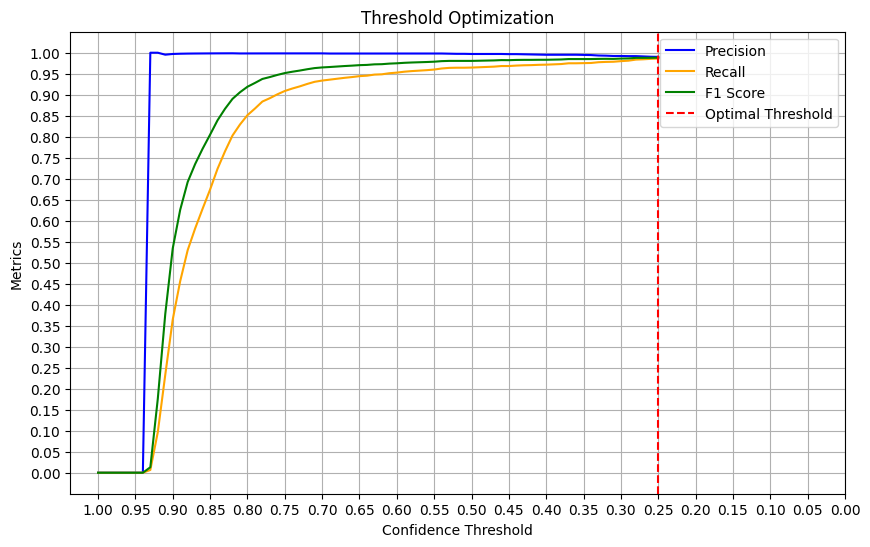

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def iou(box1, box2):
    x_min = max(box1[0], box2[0])
    y_min = max(box1[1], box2[1])
    x_max = min(box1[2], box2[2])
    y_max = min(box1[3], box2[3])

    intersection = max(0, x_max - x_min + 1) * max(0, y_max - y_min + 1)
    area1 = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
    area2 = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

def calculate_pr_curve(csv_file, iou_threshold=0.4):
    data = pd.read_csv(csv_file)

    print(f"{'Threshold':<10}{'Precision':<10}{'Recall':<10}{'F1 Score':<15}{'TP':<10}{'FP':<10}{'Missing':<10}")
    print("-" * 40)
    all_tp = []
    all_fp = []
    all_fn = []
    all_confidences = []

    total_ground_truth = 0
    for _, row in data.iterrows():
        if not row['Predicted_Confidences'] or not row['Predicted_Boxes']:
            continue

        confidences = eval(row['Predicted_Confidences'])
        # if((len(confidences)))> 1:
        #     print(confidences)
        pred_boxes = eval(row['Predicted_Boxes'])
        gt_boxes = eval(row['Ground_Truth_Boxes'])

        total_ground_truth += len(gt_boxes) 

        matched_gt = set()
        tp = 0
        fp = 0

        for conf, pred_box in zip(confidences, pred_boxes):
            match_found = False
            for i, gt_box in enumerate(gt_boxes):
                if i not in matched_gt and iou(pred_box, gt_box) >= iou_threshold:
                    match_found = True
                    matched_gt.add(i)
                    all_tp.append(1)
                    all_fp.append(0)
                    all_confidences.append(conf)
                    # tp += 1
                    break
            if not match_found:
                # fp += 1
                all_tp.append(0) 
                all_fp.append(1) 
                all_confidences.append(conf)


    # thresholds = np.linspace(0.25, 1, 100)
    # thresholds = [0.15, 0.18, 0.20, 0.23, 0.25, 0.28, 0.30, 0.33, 0.35, 0.38, 0.40, 0.43, 0.45, 0.48, 0.50, 0.53, 0.55, 
    #               0.58, 0.60, 0.63, 0.65, 0.68, 0.70, 0.73, 0.75, 0.78, 0.80, 0.83, 0.85, 0.88, 0.9, 0.93, 0.95, 0.98, 1]


    thresholds = [0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 
     0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 
     0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9,
     0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]

    precisions = []
    recalls = []
    results = []
    best_threshold = 0
    best_f1 = 0

    for t in thresholds:
        tp = sum([tp for conf, tp in zip(all_confidences, all_tp) if conf >= t])

        fp = sum([fp for conf, fp in zip(all_confidences, all_fp) if conf >= t])
        fn = total_ground_truth- tp 

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

        results.append((t, precision, recall, f1))
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

        print(f"{t:<10.2f}{precision:<10.4f}{recall:<10.4f}{f1:<10.4f}{tp:>10}{fp:>10}{fn:>10}")
        
    print("Optimal thershold: ", best_threshold)
    # plt.figure(figsize=(8, 6))
    # plt.plot(recalls, precisions, label='PR Curve', color='blue')
    # plt.xlabel('Recall')
    # plt.ylabel('Precision')
    # plt.title('Precision-Recall Curve')
    # plt.grid()
    # plt.legend()
    # plt.show()

    thresholds, precisions, recalls, f1_scores = zip(*results)

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions, label='Precision', color='blue')
    plt.plot(thresholds, recalls, label='Recall', color='orange')
    plt.plot(thresholds, f1_scores, label='F1 Score', color='green')
    plt.axvline(best_threshold, color='red', linestyle='--', label='Optimal Threshold')
    plt.xlabel('Confidence Threshold')
    plt.ylabel('Metrics')
    plt.title('Threshold Optimization')
    plt.legend()
    plt.grid()
    plt.gca().invert_xaxis()
    ticks = np.arange(0, 1.05, 0.05)[::-1]
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.show()

# csv_file = '/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/predictions_and_ground_truth.csv'
# csv_file = '/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/withcts_predictions_and_ground_truth.csv'
# csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/5videos_predictions_and_ground_truth.csv"
# csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/merged_output.csv"

# PERSON
# csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/2_person_5videos_predictions_and_ground_truth.csv"

# csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/2_person_5videos_predictions_and_ground_truth.csv"
# csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/person_withcts_predictions_and_ground_truth.csv"

#FACE
# csv_file ="/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/face_withcts_predictions_and_ground_truth.csv"
csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/optimal_thershold/face+5videos_predictions_and_ground_truth.csv"

calculate_pr_curve(csv_file)

In [56]:
from sentence_transformers import CrossEncoder 
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

/home/ajeet/codework/venv_visionwork/lib/python3.8/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
2025-01-02 15:53:13.203759: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-02 15:53:13.981054: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-02 15:53:15.207306: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/ajeet/codework/venv_visionwork/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initializatio

In [65]:
query = "What is my name"

retrieved_documents = ["My name is ajeet", "delhi is the capotal of India", "His name is ajay", "her name is priya"]

pairs = [[query, doc] for doc in retrieved_documents] 
scores = cross_encoder.predict(pairs) 

print("Scores:")
for score in scores:

    print(score)  

Scores:
3.6325946
-9.983282
-5.7279997
-5.976016


In [64]:
for o in np.argsort(scores)[::-1]:
    print(o+1)

1
3
4
2


In [66]:
num_params = sum(p.numel() for p in cross_encoder.parameters())

# Check the model size in terms of parameters
print(f"Model size (parameters): {num_params / 1e6:.2f} million parameters")

AttributeError: 'CrossEncoder' object has no attribute 'parameters'

In [68]:
from langchain.text_splitter import MarkdownTextSplitter
# Sample Markdown text
markdown_text = """
# Fun in California
## Driving
Try driving on the 1 down to San Diego
### Food
Make sure to eat a burrito while you're there
## Hiking
Go to Yosemite
"""
# Initialize the Markdown text splitter
splitter = MarkdownTextSplitter(chunk_size=40, chunk_overlap=0)
# Create documents using the text splitter
documents = splitter.create_documents([markdown_text])
# Display the created documents
for doc in documents:
    print(doc.page_content)
    print("-----------")

# Fun in California
## Driving
-----------
Try driving on the 1 down to San Diego
-----------
### Food
-----------
Make sure to eat a burrito while you're
-----------
there
-----------
## Hiking
Go to Yosemite
-----------


In [70]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import faiss

# Sample corpus
documents = [
    "The cat is on the mat.",
    "The dog is in the yard.",
    "Cats and dogs are friendly animals.",
    "I love programming in Python."
]

# Step 1: Dense Index (FAISS)
dense_model = SentenceTransformer('all-MiniLM-L6-v2')
dense_embeddings = dense_model.encode(documents)
dimension = dense_embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(dense_embeddings)

# Step 2: Sparse Index (BM25)
tfidf = TfidfVectorizer().fit(documents)
sparse_matrix = tfidf.transform(documents)

# Step 3: Query
query = "friendly pets"
dense_query = dense_model.encode([query])[0]
sparse_query = tfidf.transform([query])

# Step 4: Dense Retrieval
_, dense_results = faiss_index.search(dense_query.reshape(1, -1), k=2)
dense_scores = {idx: 1.0 / (rank + 1) for rank, idx in enumerate(dense_results[0])}

# Step 5: Sparse Retrieval
sparse_scores = sparse_matrix.dot(sparse_query.T).toarray().flatten()
sparse_scores = {idx: score for idx, score in enumerate(sparse_scores)}

# Step 6: Hybrid Score Fusion
hybrid_scores = {}
alpha = 0.5  # Weight for dense scores
for idx in range(len(documents)):
    hybrid_scores[idx] = alpha * dense_scores.get(idx, 0) + (1 - alpha) * sparse_scores[idx]

# Step 7: Rank and Retrieve
ranked_results = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)
top_k_docs = [documents[idx] for idx, _ in ranked_results[:2]]

# Output top documents
print("Top Retrieved Documents:", top_k_docs)



ModuleNotFoundError: No module named 'faiss'

In [71]:
from rank_bm25 import BM25Okapi

corpus = [
    "The cat, commonly referred to as the domestic cat or house cat, is a small domesticated carnivorous mammal.",
    "The dog is a domesticated descendant of the wolf.",
    "Humans are the most common and widespread species of primate, and the last surviving species of the genus Homo.",
    "The scientific name Felis catus was proposed by Carl Linnaeus in 1758"
]
tokenized_corpus = [doc.split(" ") for doc in corpus]

bm25 = BM25Okapi(tokenized_corpus)

In [73]:
bm25

In [72]:
query = "The cat"
tokenized_query = query.split(" ")

In [74]:
doc_scores = bm25.get_scores(tokenized_query)
doc_scores

array([0.92061135, 0.20898199, 0.        , 0.18788848])

In [78]:
import numpy as np

def scores_to_ranking(scores):
    """Convert float scores into int rankings (rank 1 is the best)"""
    return np.argsort(scores)[::-1] + 1


def rrf(keyword_rank: int, semantic_rank: int) -> float:
    """Combine keyword rank and semantic rank into a hybrid score."""
    k = 60
    rrf_score = 1 / (k + keyword_rank) + 1 / (k + semantic_rank)
    return rrf_score

In [79]:
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def hybrid_search(
    query: str, corpus, encoder_model: SentenceTransformer
) :
    # bm25
    tokenized_corpus = [doc.split(" ") for doc in corpus]
    tokenized_query = query.split(" ")
    bm25 = BM25Okapi(tokenized_corpus)
    bm25_scores = bm25.get_scores(tokenized_query)
    bm25_ranking = scores_to_ranking(bm25_scores)

    # embeddings
    document_embeddings = model.encode(corpus)
    query_embedding = model.encode(query)
    cos_sim_scores = cos_sim(document_embeddings, query_embedding).flatten().tolist()
    cos_sim_ranking = scores_to_ranking(cos_sim_scores)

    # combine rankings into RRF scores
    hybrid_scores = []
    for i, doc in enumerate(corpus):
        document_ranking = rrf(bm25_ranking[i], cos_sim_ranking[i])
        print(f"Document {i} has the rrf score {document_ranking}")
        hybrid_scores.append(document_ranking)

    # convert RRF scores into final rankings
    hybrid_ranking = scores_to_ranking(hybrid_scores)
    return hybrid_ranking

In [80]:
hybrid_ranking = hybrid_search(
    query="What is the scientifc name for cats?", corpus=corpus, encoder_model=model
)

Document 0 has the rrf score 0.03125
Document 1 has the rrf score 0.032266458495966696
Document 2 has the rrf score 0.03225806451612903
Document 3 has the rrf score 0.032266458495966696


In [89]:

import faiss


from langchain_text_splitters import RecursiveCharacterTextSplitter
from openai import OpenAI



client = OpenAI()

original_query="How does climate change affect polar bears?"
system_prompt="You are an expert in climate change and arctic life."
hyde_prompt=f"Generate an answer to the question: {original_query}"
# Make the API call passing the augmented prompt to the LLM
response = client.chat.completions.create(
  model="gpt-4o-mini",
  messages= [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": hyde_prompt}
  ]
)

# Extract the answer from the response object
answer=response.choices[0].message.content

OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

In [104]:
import pandas as pd
from sklearn.utils import shuffle

# Load the dataset
csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/FPs_heuristics/yolo_cellphone_features.csv"
data = pd.read_csv(csv_file)

# Separate the positive and negative classes
positives = data[data['label'] == 1]
negatives = data[data['label'] == 0]

# Find the minimum class size
min_class_size = min(len(positives), len(negatives))

# Sample equal number of positives and negatives
balanced_positives = positives.sample(n=min_class_size, random_state=42)
balanced_negatives = negatives.sample(n=min_class_size, random_state=42)

# Combine and shuffle the balanced dataset
balanced_data = pd.concat([balanced_positives, balanced_negatives])
balanced_data = shuffle(balanced_data, random_state=42)

# Reset index
balanced_data.reset_index(drop=True, inplace=True)

# Save or proceed with balanced data
balanced_data.to_csv("/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/FPs_heuristics/balanced_yolo_cellphone_features.csv", index=False)

print("Balanced dataset created with equal positives and negatives.")


Balanced dataset created with equal positives and negatives.


In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Load the CSV file containing the features and labels
csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/FPs_heuristics/yolo_cellphone_features.csv"
# csv_file = "/home/ajeet/codework/visionworkajeet/models/my_visionwork/models/clip/phone/FPs_heuristics/balanced_yolo_cellphone_features.csv"
data = pd.read_csv(csv_file)

# Separate the features and labels
X = data[['area', 'aspect_ratio']]  # Features
y = data['label']  # Labels

# Normalize or Standardize the features
scaler = StandardScaler()  # You can use MinMaxScaler() for normalization instead
X_scaled = scaler.fit_transform(X)  # Apply scaling to the features

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
lr_model = LogisticRegression(max_iter=1000000)  # You can adjust max_iter if convergence issues occur
lr_model.fit(X_train, y_train)

# import joblib
# joblib.dump(lr_model, "/home/ajeet/visionwork_lr_model.pkl")


LogisticRegression(max_iter=1000000)

In [2]:
# Predict on the test set
y_pred = lr_model.predict(X_test)

# Evaluate the model performance
print("Logistic Regression Model Performance:")
print(classification_report(y_test, y_pred))

# # Optionally, save the trained model

Logistic Regression Model Performance:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82      4996
           1       0.00      0.00      0.00      2149

    accuracy                           0.70      7145
   macro avg       0.35      0.50      0.41      7145
weighted avg       0.49      0.70      0.58      7145



/home/ajeet/codework/venv_visionwork/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ajeet/codework/venv_visionwork/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ajeet/codework/venv_visionwork/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

In [3]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])